# LAE and other Source Look up examples

In this notebook, we show an example of zooming in on a HETDEX LAE detection.

In [1]:
import os.path as op
import numpy as np
from astropy.table import Column, Table, hstack, unique

from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.io import fits
from astropy.io.fits.hdu.compressed import CompImageHDU

from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales

from astropy.visualization import ZScaleInterval

import plotly.graph_objects as go
from astropy.stats import sigma_clipped_stats


In [2]:
# this is HETDEX JupyterHub datacube location
pdr_dir = '/home/jovyan/Hobby-Eberly-Public/HETDEX/pdr/pdr1/'
if not op.exists(pdr_dir):
    # edit to where your have placed your pdr1 directory
    pdr_dir = '/home/jovyan/work/pdr1/'
    
# this is the IFU look up index table
ifu_data = Table.read(op.join( pdr_dir, 'ifu-index.fits'))

In [3]:
# Create SkyCoord Object array for IFU centers
ifu_coords = SkyCoord( ra=ifu_data['ra_cen']*u.deg, dec=ifu_data['dec_cen']*u.deg)

In [4]:
# Load a list of LAE locations from the HETDEX catalog

In [5]:
lae_examples = Table.read('lae_examples.fits')

In [6]:
lae_examples.sort('sn', reverse=True) # sort in decreasing S/N

In [7]:
#cutout size
size = 10 # arcsec side of cube cutout
wsize = 40 # spectral slice size

In [8]:
# lower index is higher S/N but some of these may not be centered on the brightest continuum for AGN.
# This is because S/N is a continuum-subtracted flux to noise ratio.
i = 1050
row = lae_examples[i]

print(row)

shotid = row['shotid']
ifuslot= row['ifuslot']
wave_src = row['wave']

coord = SkyCoord( ra=row['ra']*u.deg, dec=row['dec']*u.deg)
datacube_path = op.join( pdr_dir, 'datacubes', str(shotid), 'dex_cube_{}_{}.fits'.format( shotid, ifuslot))

hdul = fits.open( datacube_path)

flux = hdul["DATA"].data
error = hdul["ERROR"].data
mask = hdul["MASK"].data

# apply mask using fill value 0.0
flux[ np.where( (mask > 0) | (flux==0.0)) ] = np.nan

header = hdul["DATA"].header

wave = np.linspace( 3470, 5540, num=1036)

wcs = WCS(header)


 detectid     ra       dec      wave     sn      shotid   ifuslot
---------- -------- --------- ------- ------- ----------- -------
3002665003 202.8343 51.551723 4231.92 6.24299 20190302024     035


In [9]:
nz, ny, nx = hdul['DATA'].shape

# first check for coverage
if not wcs.celestial.footprint_contains(coord):
    print('Not in footprint')

In [10]:
# Convert sky coordinate to pixel
x_pix, y_pix = wcs.celestial.world_to_pixel(coord)

# Get pixel scale
pixel_scale = proj_plane_pixel_scales(wcs.celestial)[0] * u.deg
pixel_scale_arcsec = pixel_scale.to(u.arcsec).value
r_pix = size / pixel_scale_arcsec / 2

# Define subcube bounds
x_min = int(np.floor(x_pix - r_pix))
x_max = int(np.ceil(x_pix + r_pix)) + 1
y_min = int(np.floor(y_pix - r_pix ))
y_max = int(np.ceil(y_pix + r_pix )) + 1

# Clip to cube bounds
x_min, x_max = max(0, x_min), min(nx, x_max)
y_min, y_max = max(0, y_min), min(ny, y_max)

wslice = np.abs( wave - wave_src) < wsize/2

# Load only subcube
flux_cube = hdul['DATA'].data[wslice, y_min:y_max, x_min:x_max].astype(float)
error_cube = hdul['ERROR'].data[wslice, y_min:y_max, x_min:x_max].astype(float)
mask_cube = hdul['MASK'].data[wslice, y_min:y_max, x_min:x_max]

In [11]:
np.shape( flux_cube)

(20, 22, 22)

In [12]:
import plotly.graph_objects as go
from astropy.stats import sigma_clipped_stats


In [13]:
# Use wavelength, y, x = flux_cube.shape
nw, ny, nx = flux_cube.shape

# Create meshgrid coordinates
wave_vals = wave[wslice]  # Actual wavelength values
x_vals = (np.arange(x_min, x_max) - x_pix) * pixel_scale_arcsec  # arcsec offset from center
y_vals = (np.arange(y_min, y_max) - y_pix) * pixel_scale_arcsec  # arcsec offset from center

# Generate coordinate arrays for each voxel
W, Y, X = np.meshgrid(wave_vals, y_vals, x_vals, indexing='ij')

# Example: replace with cube-wide median (could also use zero)
flux_cube_filled = np.nan_to_num(flux_cube, nan=0.0, posinf=0.0, neginf=0.0)

mean, median, std = sigma_clipped_stats(flux_cube_filled, sigma=3.0, maxiters=5)

## Compute background stats: mean, median, std
#mean, median, std = sigma_clipped_stats(flux_cube, sigma=3.0, maxiters=5)

# Define contrast limits, here we only plot up contours > 2 sigma
vmin = median + 2 * std
vmax = median + 5 * std

# Stretch by clipping and normalizing
stretched_flux = np.clip(flux_cube_filled, vmin, vmax)
stretched_flux = (stretched_flux - vmin) / (vmax - vmin)  # Normalize to [0, 1] 

In [14]:
# Flatten arrays
fig = go.Figure(data=go.Volume(
    x=X.flatten(),  # arcsec offset in RA
    y=Y.flatten(),  # arcsec offset in Dec
    z=W.flatten(),  # wavelength in Angstrom
    #value=flux_cube.flatten(),
    value=stretched_flux.flatten(),
    opacity=0.15,
    surface_count=11,
    colorscale="Viridis",
))

fig.update_layout(
    scene=dict(
        xaxis_title="RA Offset (arcsec)",
        yaxis_title="Dec Offset (arcsec)",
        zaxis_title="Wavelength (Å)",
        aspectmode='data',
    ),
    margin=dict(t=10, l=10, r=10, b=10)
)

# Central voxel coordinates
x_center = 0  # arcsec offset
y_center = 0  # arcsec offset
z_center = wave_src  # Angstrom

fig.add_trace(go.Scatter3d(
    x=[x_center],
    y=[y_center],
    z=[z_center],
    mode='markers',
    marker=dict(size=5, color='red', symbol='cross'),
    name='Source Center'
))

fig.show()

## ELiXer Reports

An important diagnostic for HETDEX detections is provided by the **ELiXer reports**, which are generated for every curated detection in the HETDEX catalog. A full description of these reports is given in the Appendix of Davis et al. (2023).

ELiXer reports summarize ancillary imaging and spectroscopic information at the location of each detection. They include:
- Imaging cutouts from available surveys
- Cutouts of the amplifier array showing the highest-weight fibers used in the PSF extraction
- The full HETDEX PSF-extracted spectrum with associated error
- A zoomed view of the spectral region around the detected line

These reports are used for visual validation of HETDEX detections.

This release includes **ELiXer reports for all detections** in the full supplemental HETDEX detection catalog (Appendix: Detection Info Table), including every detection in the main HPSC2 catalog.

In [15]:
from IPython.display import Image, display

In the example above we can see there are probably two LAEs in this cube. These are detected in our raw pipeline with detectids 3002665003,3002665012. Unfortunately 3002665012 is S/N=4.78 so it JUST misses our cut to make it into the catalog.

In [16]:
# plot up all detectids from previous example

det = row['detectid']

prefix = str(det)[:5]

url = f"https://web.corral.tacc.utexas.edu/hetdex/HETDEX/pdr/pdr1/detect/elixer/{prefix}/{det}.jpg"

display(Image(url=url, width=900))

# Compare dexcube/get_spectra to HETDEX pipeline spectra

We recommend you access the spectra from the catalog as suggested in Notebook 10 which consists from spectra from the curated source catalog in which detections are vetted and grouped into sources. In this section, we demonstrate access to the raw pipeline spectrum for testing purposes. Generally if a detection is found in our raw databases but not in the catalog, it likely has something wrong wtih it. But in this example, it offers a quick way to access the original spectrum and compare to the interpolated datacubes provided with the HETDEX public release.

In [17]:
import tables as tb
import matplotlib.pyplot as plt
from dexcube.get_spec import get_spectra

In [18]:
# open detection index to access pipeline detection index for the full survey
DI = tb.open_file( op.join( pdr_dir, 'detect/detect_index_hdr5.h5'), 'r')

In [19]:
#detectid_obj = 3002665003 # example LAE
#detectid_obj = 5090024720 # example OII
#detectid_obj = 5090087291 # example star
detectid_obj = 5090068724 # example AGN

det_file_info = DI.root.DetectIndex.read_where( 'detectid == detectid_obj')[0]
survey = det_file_info['survey'].decode()
det_type = det_file_info['det_type'].decode()

cw = None
if det_type == 'line':
    det_file_type = 'detect'
else:
    det_file_type = 'cont'

# Spectra, and IFU/shotid information is accessed from H5 files for each survey/detection type combination

det_file = tb.open_file( op.join( pdr_dir, f'detect/{det_file_type}_{survey}.h5'), 'r')

det_info = det_file.root.Detections.read_where('detectid == detectid_obj')[0]
coord = SkyCoord( ra= det_info['ra'], dec=det_info['dec'], unit='deg')
shotid = det_info['shotid']
ifuslot = det_info['ifuslot'].decode()

if det_type == 'line':
    cw = det_info['wave']

spec_pipeline = det_file.root.Spectra.read_where('detectid == detectid_obj')[0]

In [20]:
# get spectra from dexcubes
spec, err, ap, wave = get_spectra(
    coord, shotid, ifuslot, pdr_dir,
    radius=3.5,
    exclude_bits=None,        # or: exclude_bits=None
    include_only_bits=None, 
    return_wave=True
)


In [21]:
%matplotlib widget

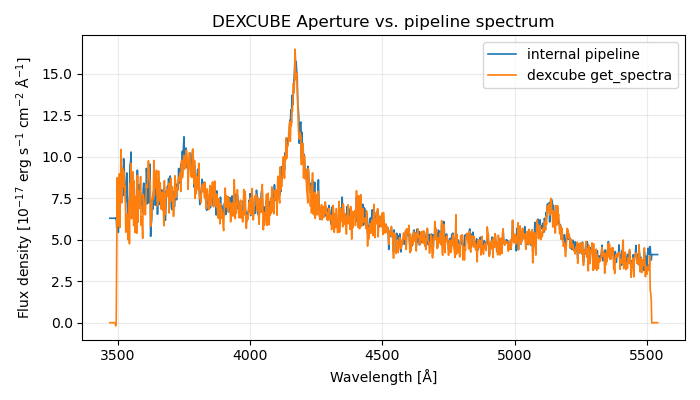

In [22]:
plt.figure(figsize=(7,4))
plt.plot(wave, spec_pipeline['spec1d'] / 2.0, label='internal pipeline', lw=1.2)
plt.plot(wave, spec, label='dexcube get_spectra', lw=1.2)

if cw is not None:
    plt.axvline(cw, color='grey', linestyle='--', lw=1)
    # optional: label the line near the top
    ymin, ymax = plt.gca().get_ylim()
    plt.text(cw, ymax*0.98, f'cw = {cw:.1f} Å', ha='right', va='top', fontsize=9, color='grey')

plt.xlabel('Wavelength [Å]')
plt.ylabel('Flux density [10$^{-17}$ erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$]')
plt.title('DEXCUBE Aperture vs. pipeline spectrum')
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()

### When you are done with the H5 files you must close them

In [23]:
det_file.close()
DI.close()